## **PIA**

#### Dataset limpio

In [24]:
import pandas as pd

df = pd.read_csv("datos_limpios.csv")
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 93000 entries, 0 to 92999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Booking ID       93000 non-null  object 
 1   Booking Status   93000 non-null  object 
 2   Customer ID      93000 non-null  object 
 3   Vehicle Type     93000 non-null  object 
 4   Pickup Location  93000 non-null  object 
 5   Drop Location    93000 non-null  object 
 6   Avg VTAT         93000 non-null  float64
 7   Avg CTAT         93000 non-null  float64
 8   Booking Value    93000 non-null  float64
 9   Ride Distance    93000 non-null  float64
 10  Driver Ratings   93000 non-null  float64
 11  Customer Rating  93000 non-null  float64
 12  Payment Method   93000 non-null  object 
 13  Datetime         93000 non-null  object 
dtypes: float64(6), object(8)
memory usage: 9.9+ MB


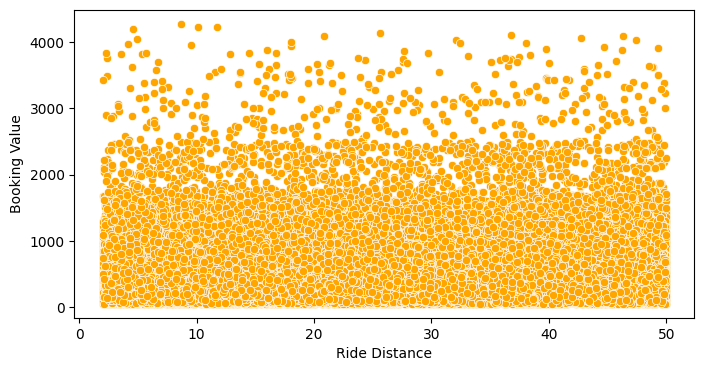

In [2]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,4))
sns.scatterplot(data=df, x='Ride Distance', y='Booking Value', color='orange')
plt.xlabel('Ride Distance')
plt.ylabel('Booking Value')
plt.show()

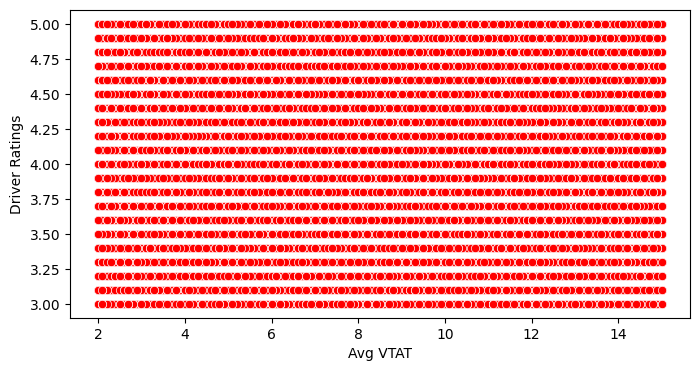

In [3]:
plt.figure(figsize=(8,4))
sns.scatterplot(data=df, x='Avg VTAT', y='Driver Ratings', color='red')
plt.xlabel('Avg VTAT')
plt.ylabel('Driver Ratings')
plt.show()

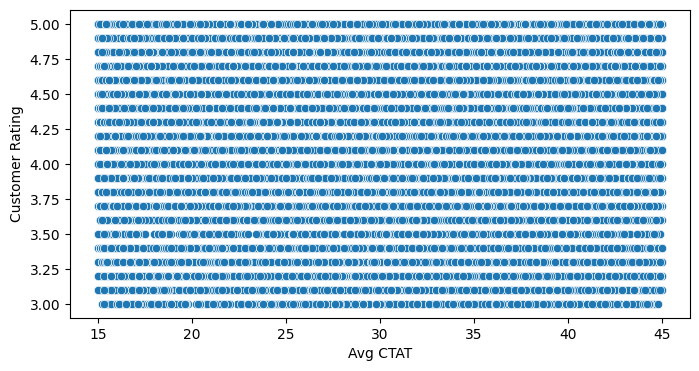

In [4]:
plt.figure(figsize=(8,4))
sns.scatterplot(data=df, x='Avg CTAT', y='Customer Rating')
plt.xlabel('Avg CTAT')
plt.ylabel('Customer Rating')
plt.show()

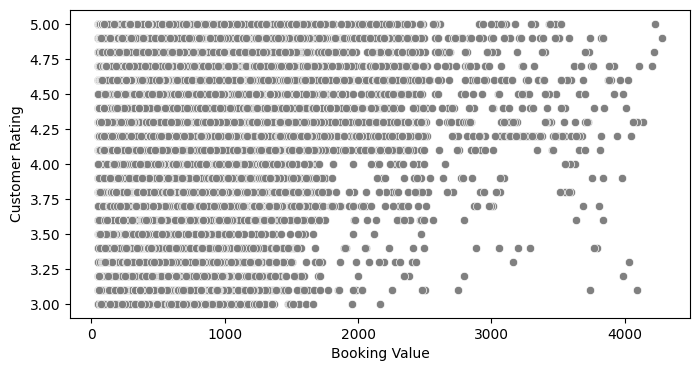

In [5]:
plt.figure(figsize=(8,4))
sns.scatterplot(data=df, x='Booking Value', y='Customer Rating', color='grey')
plt.xlabel('Booking Value')
plt.ylabel('Customer Rating')
plt.show()

In [25]:
df['Datetime'] = pd.to_datetime(df['Datetime'], errors='coerce')

df['Hora'] = df['Datetime'].dt.hour

tarifa = df.groupby('Hora')['Booking Value'].mean().reset_index()
tarifa.rename(columns={'Booking Value': 'Promedio Tarifa'}, inplace=True)

print(tarifa.to_markdown(index=False, floatfmt=".2f"))

|   Hora |   Promedio Tarifa |
|-------:|------------------:|
|   0.00 |            507.84 |
|   1.00 |            514.41 |
|   2.00 |            509.67 |
|   3.00 |            504.32 |
|   4.00 |            503.91 |
|   5.00 |            499.31 |
|   6.00 |            515.49 |
|   7.00 |            500.84 |
|   8.00 |            511.78 |
|   9.00 |            517.56 |
|  10.00 |            511.08 |
|  11.00 |            502.06 |
|  12.00 |            514.47 |
|  13.00 |            498.95 |
|  14.00 |            500.42 |
|  15.00 |            507.08 |
|  16.00 |            504.56 |
|  17.00 |            513.47 |
|  18.00 |            513.08 |
|  19.00 |            499.53 |
|  20.00 |            505.47 |
|  21.00 |            513.88 |
|  22.00 |            505.41 |
|  23.00 |            519.26 |


#### Dataset original

In [40]:
df = pd.read_csv("ncr_ride_bookings.csv")
df['Datetime'] = pd.to_datetime(df['Date'] + ' ' + df['Time'], errors='coerce')
df.drop(['Date', 'Time'], axis=1, inplace=True)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150000 entries, 0 to 149999
Data columns (total 20 columns):
 #   Column                             Non-Null Count   Dtype         
---  ------                             --------------   -----         
 0   Booking ID                         150000 non-null  object        
 1   Booking Status                     150000 non-null  object        
 2   Customer ID                        150000 non-null  object        
 3   Vehicle Type                       150000 non-null  object        
 4   Pickup Location                    150000 non-null  object        
 5   Drop Location                      150000 non-null  object        
 6   Avg VTAT                           139500 non-null  float64       
 7   Avg CTAT                           102000 non-null  float64       
 8   Cancelled Rides by Customer        10500 non-null   float64       
 9   Reason for cancelling by Customer  10500 non-null   object        
 10  Cancelled Rides by D

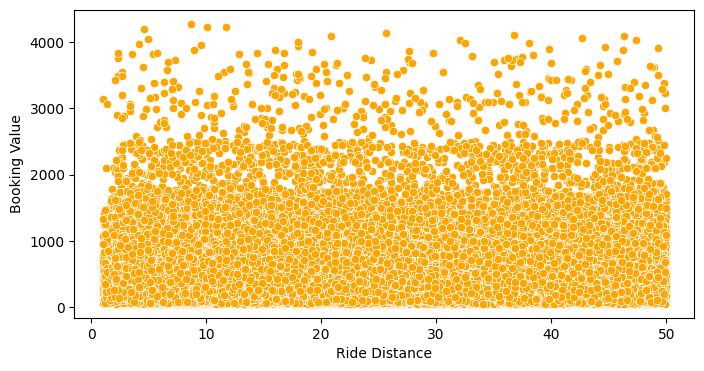

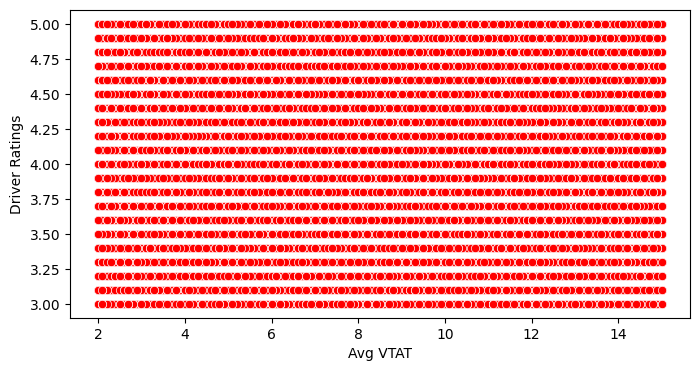

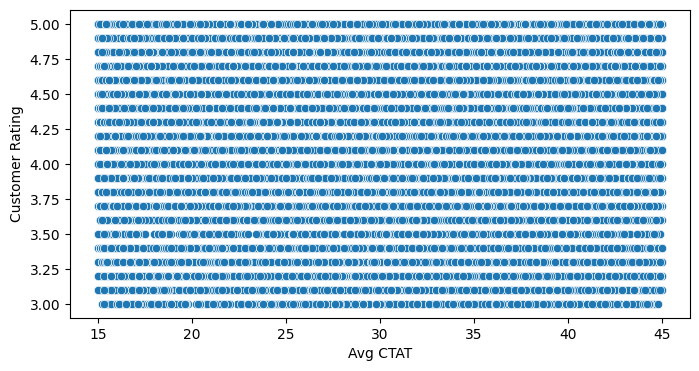

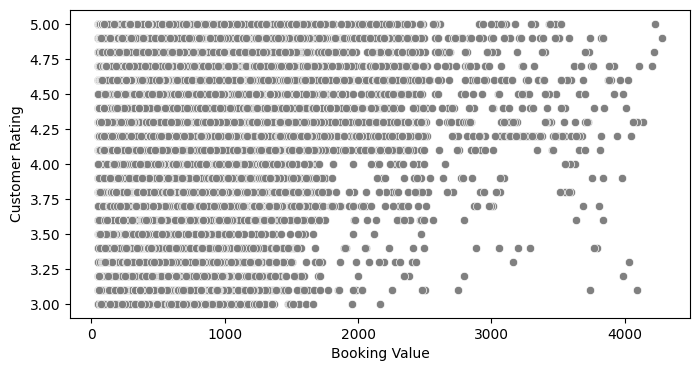

In [20]:
# sin limpieza de datos
plt.figure(figsize=(8,4))
sns.scatterplot(data=df, x='Ride Distance', y='Booking Value', color='orange')
plt.xlabel('Ride Distance')
plt.ylabel('Booking Value')
plt.show()

plt.figure(figsize=(8,4))
sns.scatterplot(data=df, x='Avg VTAT', y='Driver Ratings', color='red')
plt.xlabel('Avg VTAT')
plt.ylabel('Driver Ratings')
plt.show()

plt.figure(figsize=(8,4))
sns.scatterplot(data=df, x='Avg CTAT', y='Customer Rating')
plt.xlabel('Avg CTAT')
plt.ylabel('Customer Rating')
plt.show()

plt.figure(figsize=(8,4))
sns.scatterplot(data=df, x='Booking Value', y='Customer Rating', color='grey')
plt.xlabel('Booking Value')
plt.ylabel('Customer Rating')
plt.show()

In [41]:
df['Booking Value'] = df['Booking Value'].astype(str).str.replace('"', '', regex=False).str.strip()
df['Booking Value'] = pd.to_numeric(df['Booking Value'], errors='coerce')

df['Datetime'] = pd.to_datetime(df['Datetime'], errors='coerce')

df.dropna(subset=['Booking Value', 'Datetime'], inplace=True)

df['Hora'] = df['Datetime'].dt.hour

tarifa = df.groupby('Hora')['Booking Value'].mean().reset_index()
tarifa.rename(columns={'Booking Value': 'Promedio Tarifa'}, inplace=True)

print(tarifa.to_markdown(index=False, floatfmt=".2f"))

|   Hora |   Promedio Tarifa |
|-------:|------------------:|
|   0.00 |            507.77 |
|   1.00 |            515.64 |
|   2.00 |            508.92 |
|   3.00 |            505.72 |
|   4.00 |            508.94 |
|   5.00 |            499.58 |
|   6.00 |            516.70 |
|   7.00 |            503.10 |
|   8.00 |            512.72 |
|   9.00 |            516.88 |
|  10.00 |            510.71 |
|  11.00 |            503.44 |
|  12.00 |            511.02 |
|  13.00 |            500.12 |
|  14.00 |            505.05 |
|  15.00 |            507.97 |
|  16.00 |            505.49 |
|  17.00 |            511.22 |
|  18.00 |            510.54 |
|  19.00 |            497.86 |
|  20.00 |            506.91 |
|  21.00 |            515.00 |
|  22.00 |            506.69 |
|  23.00 |            517.68 |


In [46]:
# con limpieza de datos
df = pd.read_csv("ncr_ride_bookings.csv")
df.isna().sum()

,0
Date,0
Time,0
Booking ID,0
Booking Status,0
Customer ID,0
Vehicle Type,0
Pickup Location,0
Drop Location,0
Avg VTAT,10500
Avg CTAT,48000


In [47]:
df['Reason for cancelling by Customer'] = df['Reason for cancelling by Customer'].fillna('Not cancelled')
df['Driver Cancellation Reason'] = df['Driver Cancellation Reason'].fillna('Not cancelled')
df['Incomplete Rides Reason'] = df['Incomplete Rides Reason'].fillna('Not incomplete')
df['Payment Method'] = df['Payment Method'].fillna('Cancelled or incomplete ride')

col_num = [
    'Cancelled Rides by Driver',
    'Cancelled Rides by Customer',
    'Incomplete Rides',
    'Booking Value',
    'Ride Distance',
    'Driver Ratings',
    'Customer Rating',
    'Avg CTAT',
    'Avg VTAT'
]

for col in col_num:
    df[col] = df[col].fillna(0)

df['Time'] = pd.to_datetime(df['Time'])
df['Date'] = pd.to_datetime(df['Date'])


/tmp/ipython-input-1102523484.py:21: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['Time'] = pd.to_datetime(df['Time'])


In [48]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150000 entries, 0 to 149999
Data columns (total 21 columns):
 #   Column                             Non-Null Count   Dtype         
---  ------                             --------------   -----         
 0   Date                               150000 non-null  datetime64[ns]
 1   Time                               150000 non-null  datetime64[ns]
 2   Booking ID                         150000 non-null  object        
 3   Booking Status                     150000 non-null  object        
 4   Customer ID                        150000 non-null  object        
 5   Vehicle Type                       150000 non-null  object        
 6   Pickup Location                    150000 non-null  object        
 7   Drop Location                      150000 non-null  object        
 8   Avg VTAT                           150000 non-null  float64       
 9   Avg CTAT                           150000 non-null  float64       
 10  Cancelled Rides by C

In [49]:
df['Hour'] = df['Time'].dt.hour

tarifa = df.groupby('Hour')['Booking Value'].mean().reset_index()
tarifa.rename(columns={'Booking Value': 'Promedio Tarifa'}, inplace=True)

print(tarifa.to_markdown(index=False, floatfmt=".2f"))

|   Hour |   Promedio Tarifa |
|-------:|------------------:|
|   0.00 |            347.64 |
|   1.00 |            343.51 |
|   2.00 |            355.37 |
|   3.00 |            339.71 |
|   4.00 |            344.43 |
|   5.00 |            334.07 |
|   6.00 |            353.62 |
|   7.00 |            339.80 |
|   8.00 |            348.99 |
|   9.00 |            351.22 |
|  10.00 |            349.02 |
|  11.00 |            346.29 |
|  12.00 |            346.03 |
|  13.00 |            339.75 |
|  14.00 |            339.84 |
|  15.00 |            343.66 |
|  16.00 |            345.02 |
|  17.00 |            349.30 |
|  18.00 |            344.28 |
|  19.00 |            336.25 |
|  20.00 |            346.79 |
|  21.00 |            356.36 |
|  22.00 |            341.30 |
|  23.00 |            352.74 |


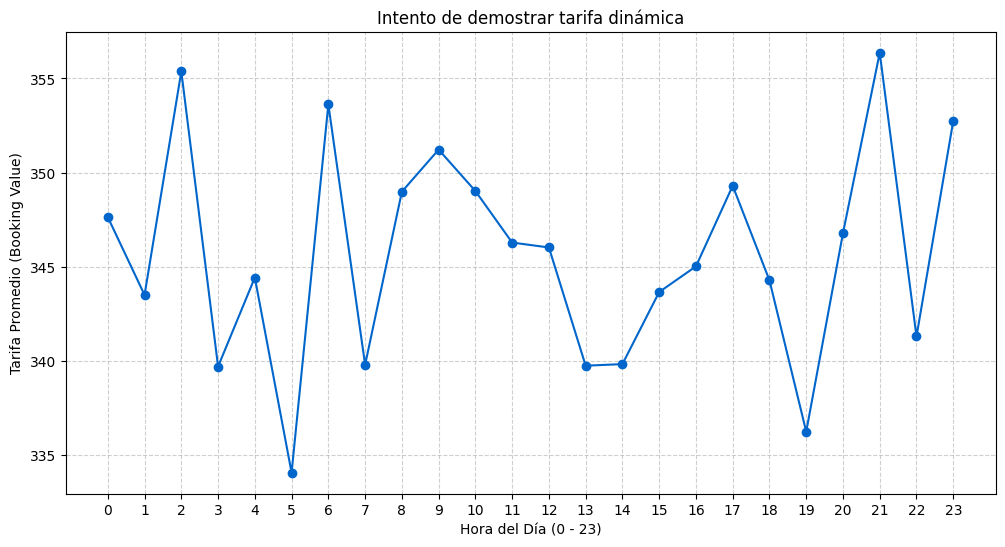

In [52]:
plt.figure(figsize=(12, 6))
plt.plot(tarifa['Hour'], tarifa['Promedio Tarifa'], marker='o', linestyle='-', color='#0066CC')
plt.title('Intento de demostrar tarifa dinámica')
plt.xlabel('Hora del Día (0 - 23)')
plt.ylabel('Tarifa Promedio (Booking Value)')
plt.xticks(range(24))
plt.grid(True, linestyle='--', alpha=0.6)

In [57]:
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier

In [61]:
X, y = df.drop(columns=['Date','Time','Hour','Booking Status','Booking ID']), df['Booking Status']

le = LabelEncoder()
X = X.apply(lambda col: le.fit_transform(col.astype(str)) if col.dtypes == 'object' else col)
y = le.fit_transform(y)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

knn = KNeighborsClassifier()
knn.fit(X_train, y_train)

y_pred = knn.predict(X_test)

print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")

Accuracy: 0.7620


In [67]:
decision_tree = DecisionTreeClassifier(max_depth=2)
decision_tree.fit(X_train, y_train)

y_pred = decision_tree.predict(X_test)

print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")

Accuracy: 0.8717
